In [177]:
import kagglehub
import os
import pandas as pd
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif


Загружаем датасет

In [178]:
path = kagglehub.dataset_download("wenruliu/adult-income-dataset")

csv_path = os.path.join(path, "adult.csv")
df = pd.read_csv(csv_path)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [179]:
df

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


Удаляем ненужную переменную fnlwgt, т к она показывает количество опрашиваемых людей с такими же данными

In [180]:
data = df.copy()
if 'fnlwgt' in data.columns:
    data = data.drop(columns=['fnlwgt'])

Проверяем зависимость каждого признака, сначала категориальных по хи-квадрат тесту, а потом численных по т-тесту

In [181]:
categorical_features = ['gender', 'race', 'workclass', 'education', 'marital-status', 'occupation', 'relationship', 'native-country']

target = 'income'

selected_features = []

for col in categorical_features:
    contingency_table = pd.crosstab(df[col], df[target])

    chi2, p, dof, ex = chi2_contingency(contingency_table)

    status = "Зависим (Полезен)" if p < 0.05 else "Независим (Бесполезен)"

    print(f"Признак: {col:15} | P-value: {p:.4e} | Статус: {status}")

    if p < 0.05:
        selected_features.append(col)

print("\nОтобранные признаки:", selected_features)

Признак: gender          | P-value: 0.0000e+00 | Статус: Зависим (Полезен)
Признак: race            | P-value: 4.2844e-104 | Статус: Зависим (Полезен)
Признак: workclass       | P-value: 0.0000e+00 | Статус: Зависим (Полезен)
Признак: education       | P-value: 0.0000e+00 | Статус: Зависим (Полезен)
Признак: marital-status  | P-value: 0.0000e+00 | Статус: Зависим (Полезен)
Признак: occupation      | P-value: 0.0000e+00 | Статус: Зависим (Полезен)
Признак: relationship    | P-value: 0.0000e+00 | Статус: Зависим (Полезен)
Признак: native-country  | P-value: 1.0356e-70 | Статус: Зависим (Полезен)

Отобранные признаки: ['gender', 'race', 'workclass', 'education', 'marital-status', 'occupation', 'relationship', 'native-country']


In [182]:
num_features = ['age', 'educational-num', 'hours-per-week', "capital-gain", "capital-loss"]
target = 'income'

print("Результаты T-теста для числовых признаков:\n")

for col in num_features:
    # Разделяем данные на две группы по доходу
    group1 = df[df[target] == '<=50K'][col]
    group2 = df[df[target] == '>50K'][col]

    # Проводим T-тест
    t_stat, p = ttest_ind(group1, group2)

    status = "Зависим (Полезен)" if p < 0.05 else "Независим (Бесполезен)"
    print(f"Признак: {col:15} | P-value: {p:.4e} | Статус: {status}")

    if p < 0.05:
        selected_features.append(col)

print("\nОтобранные признаки:", selected_features)

Результаты T-теста для числовых признаков:

Признак: age             | P-value: 0.0000e+00 | Статус: Зависим (Полезен)
Признак: educational-num | P-value: 0.0000e+00 | Статус: Зависим (Полезен)
Признак: hours-per-week  | P-value: 0.0000e+00 | Статус: Зависим (Полезен)
Признак: capital-gain    | P-value: 0.0000e+00 | Статус: Зависим (Полезен)
Признак: capital-loss    | P-value: 8.5436e-236 | Статус: Зависим (Полезен)

Отобранные признаки: ['gender', 'race', 'workclass', 'education', 'marital-status', 'occupation', 'relationship', 'native-country', 'age', 'educational-num', 'hours-per-week', 'capital-gain', 'capital-loss']


Кодируем категориальную переменную в 0 и 1

In [183]:
le_target = LabelEncoder()
data['income'] = le_target.fit_transform(data['income'])

Переводим остальные категориальные переменные в цифры

In [184]:
categorical_cols = data.select_dtypes(include=['object']).columns
le_features = LabelEncoder()

for col in categorical_cols:
    data[col] = le_features.fit_transform(data[col])

In [185]:
X = data.drop(columns=['income'])
y = data['income']

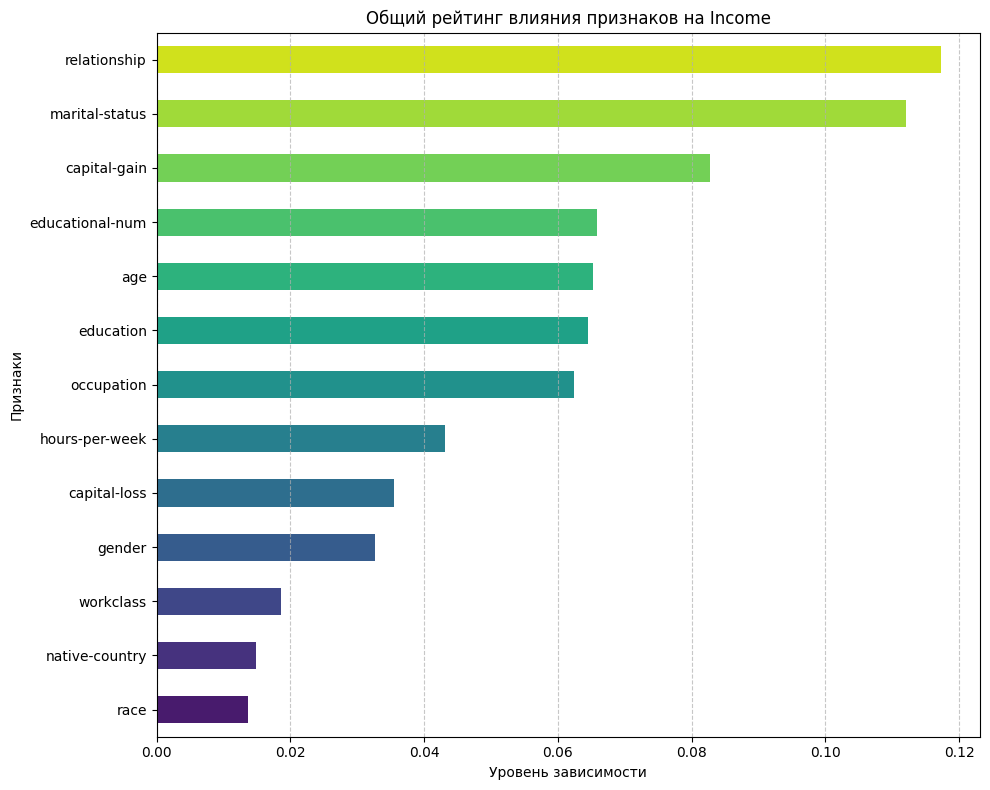

In [186]:
discrete_features = [X.columns.get_loc(col) for col in categorical_features]

importances = mutual_info_classif(X, y, random_state=42)

feature_importance = pd.Series(importances, index=X_all.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
colors = sns.color_palette("viridis", len(feature_importance))
feature_importance.plot(kind='barh', color=colors)

plt.title('Общий рейтинг влияния признаков на Income')
plt.xlabel('Уровень зависимости')
plt.ylabel('Признаки')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

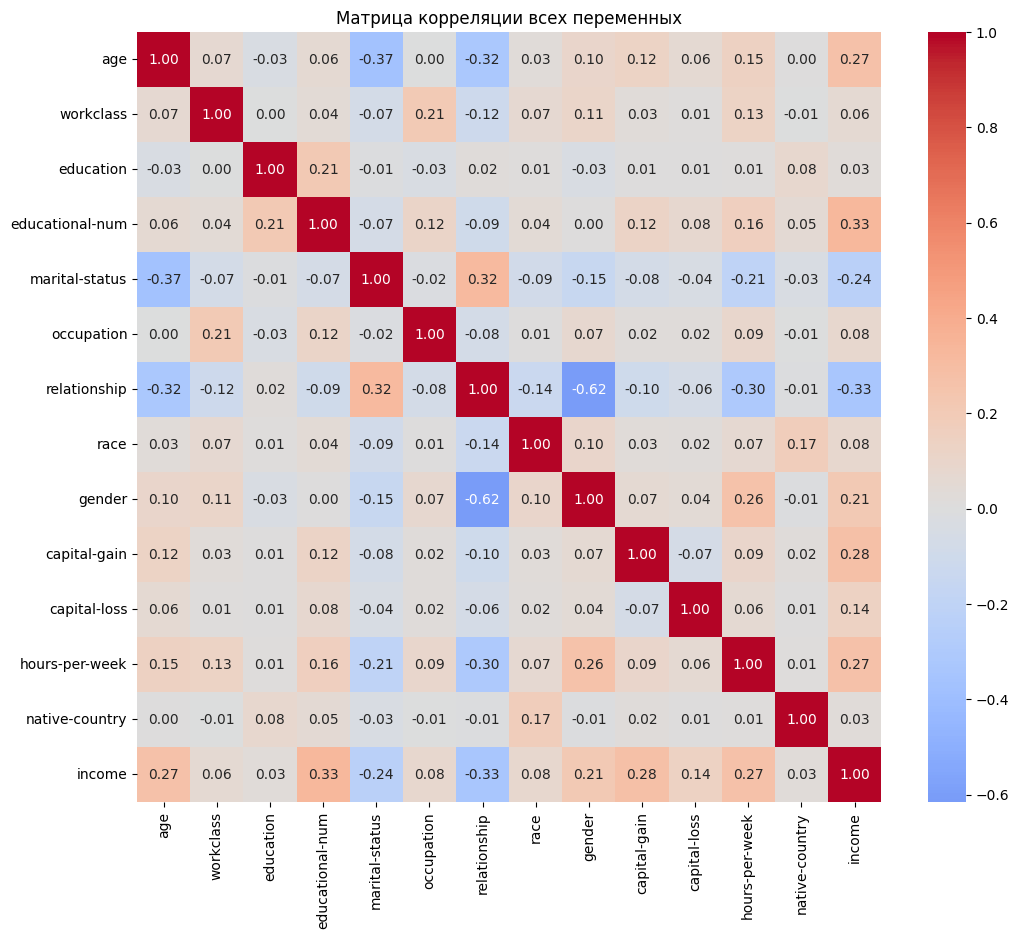

In [187]:
corr_matrix = data.corr(method='spearman')

plt.figure(figsize=(12, 10))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)

plt.title('Матрица корреляции всех переменных')
plt.show()

Делим на атрибуты на подклассы. Делим по логике, 1ая группа будет отвечать за демографические признаки, 2ая за профессиональные, 3я за финансовую историю + два пересекающихся признака с остальными подклассами

In [188]:
C1 = ['age', 'gender', 'race', 'native-country', 'relationship']
C2 = ['workclass', 'educational-num', 'occupation', 'hours-per-week', 'marital-status']
C3 = ['capital-gain', 'capital-loss', 'hours-per-week', 'age']

Видим дисбаланс классов

In [189]:
data['income'].value_counts()

income
0    37155
1    11687
Name: count, dtype: int64

Делим на обучающую и тестовую выборки

In [190]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Обучаем наивный Гауссовский Байесовский классификатор

In [191]:
def evaluate_model(feature_list, name):
    print(f"\n--- Анализ модели: {name} ---")

    model = GaussianNB()
    model.fit(X_train[feature_list], y_train)

    y_pred = model.predict(X_test[feature_list])

    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")

    print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))

    return model

In [192]:
nb_model_1 = evaluate_model(C1, "C1 (Демография)")


--- Анализ модели: C1 (Демография) ---
Accuracy: 0.7564
              precision    recall  f1-score   support

       <=50K       0.86      0.81      0.84      7479
        >50K       0.48      0.58      0.53      2290

    accuracy                           0.76      9769
   macro avg       0.67      0.69      0.68      9769
weighted avg       0.77      0.76      0.76      9769



In [193]:
nb_model_2 = evaluate_model(C2, "C2 (Профессия)")


--- Анализ модели: C2 (Профессия) ---
Accuracy: 0.8243
              precision    recall  f1-score   support

       <=50K       0.85      0.93      0.89      7479
        >50K       0.68      0.48      0.56      2290

    accuracy                           0.82      9769
   macro avg       0.76      0.71      0.73      9769
weighted avg       0.81      0.82      0.81      9769



In [194]:
nb_model_3 = evaluate_model(C3, "C3 (Финансы)")


--- Анализ модели: C3 (Финансы) ---
Accuracy: 0.7989
              precision    recall  f1-score   support

       <=50K       0.82      0.95      0.88      7479
        >50K       0.65      0.31      0.42      2290

    accuracy                           0.80      9769
   macro avg       0.73      0.63      0.65      9769
weighted avg       0.78      0.80      0.77      9769



Самая большая точность получилась на 2ом подклассе, тут самый высокий баланс точности.

У модели на 1ом подклассе самая низкая точность, но самый высокий recall для класса >50K (0.48). Это значит, что она склонна чаще называть людей богатыми, но при этом она часто ошибается (precision для >50K = 0.48).


Модель на 3ем подклассе хорошо находит людей с низким доходом (recall для <=50K = 0.95), но плохо выделяет богатых (recall для >50K всего 0.31). Это связано с тем, что данные о прибыли (capital-gain) очень разряжены.

In [195]:
def plot_conf_matrix(model, feature_list, name):
    y_pred = model.predict(X_test[feature_list])
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['<=50K', '>50K'],
                yticklabels=['<=50K', '>50K'])
    plt.title(f'Матрица ошибок: {name}')
    plt.ylabel('Реальность')
    plt.xlabel('Предсказание')
    plt.show()

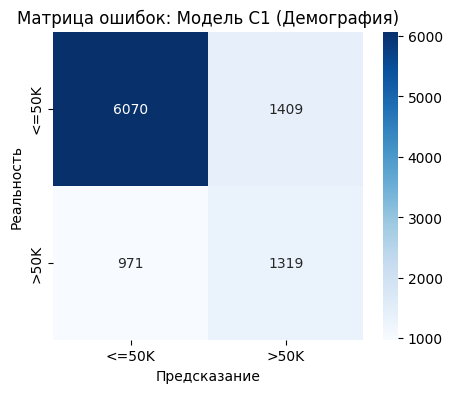

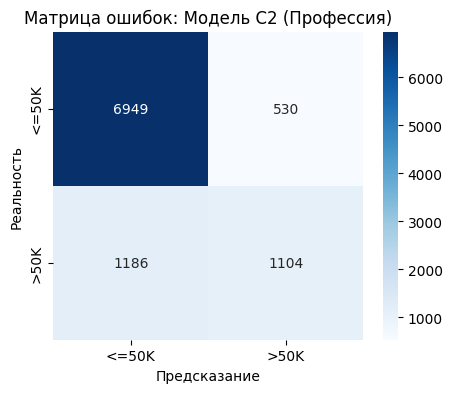

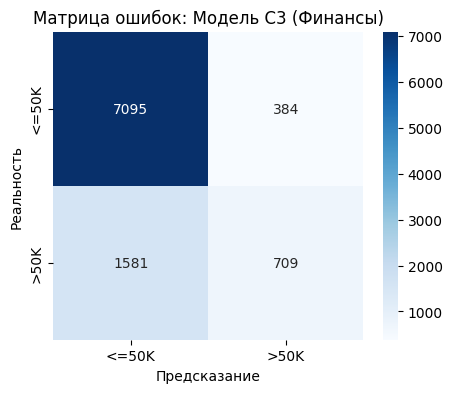

In [196]:
plot_conf_matrix(nb_model_1, C1, "Модель C1 (Демография)")
plot_conf_matrix(nb_model_2, C2, "Модель C2 (Профессия)")
plot_conf_matrix(nb_model_3, C3, "Модель C3 (Финансы)")

In [197]:
def calculate_log_likelihood(model, feature_list, X_test_df, y_test_series):
    jll = model._joint_log_likelihood(X_test_df[feature_list])

    actual_log_probs = []
    for i, target_class in enumerate(y_test_series):
        actual_log_probs.append(jll[i, target_class])

    total_ll = np.sum(actual_log_probs)
    return total_ll

In [198]:
ll1 = calculate_log_likelihood(nb_model_1, C1, X_test, y_test)
ll2 = calculate_log_likelihood(nb_model_2, C2, X_test, y_test)
ll3 = calculate_log_likelihood(nb_model_3, C3, X_test, y_test)

print(f"Total Log-Likelihood C1: {ll1:.2f}")
print(f"Total Log-Likelihood C2: {ll2:.2f}")
print(f"Total Log-Likelihood C3: {ll3:.2f}")

Total Log-Likelihood C1: -114894.20
Total Log-Likelihood C2: -128410.53
Total Log-Likelihood C3: -240925.34


По правдоподобию модель на C1 лучше. Можем предположить это связано с тем, что возраст и демографические данные распределены более плавно, и Гауссовскому классификатору легче их описывать. А на C2 модель имеет более высокую точность, потому что признаки (образование, работа) информативнее для предсказания дохода, но не идеально соответствуют нормальному распределению.

Попробуем обучит наивный категориальный байес только для категориальных признаков из 2го подкласса

In [199]:
С4 = ['relationship', 'marital-status', 'education', 'occupation', 'native-country', 'workclass', 'race']


In [200]:
model = CategoricalNB()
model.fit(X_train[C4], y_train)

y_pred = model.predict(X_test[C4])

print(f"Accuracy: {accuracy_score(y_test, y_pred_cat):.4f}")
print(classification_report(y_test, y_pred_cat))

Accuracy: 0.8294
              precision    recall  f1-score   support

           0       0.87      0.91      0.89      7479
           1       0.66      0.56      0.60      2290

    accuracy                           0.83      9769
   macro avg       0.77      0.73      0.75      9769
weighted avg       0.82      0.83      0.82      9769



Метрика улучшилась, потому что мы взяли независимые друг от друга категориальные фичи.